# TMDPDF Plots

Card-driven notebook for plotting the TMDPDF in `b` space and `k_T` space.

The active parameterization and parameter values come from `Cards/<fit_name>.jl`.
The Julia NP file is inferred from the card's `NP_name` by replacing `.cl` with `.jl` under `TMDs/NP Parameterizations Julia`.

This follows the same card-first logic as `TMDs/predict.ipynb` and uses `TMDs/Grids/initialization.jl` to load the grid-based TMD inputs selected by the card's `table_name`.

The default plots are arranged in a MAP-style presentation: fixed `Q`, several `x` values, and final 3D surfaces in `(x, b)` and `(x, k_T)`.

In [1]:
from julia.api import Julia
from julia import Main

import os
import json
from pathlib import Path
from shutil import which

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from tqdm import tqdm

if which('latex'):
    plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'
    plt.rc('font', **{'family': 'sans-serif', 'sans-serif': ['Helvetica']})
    plt.rc('text', usetex=True)
else:
    plt.rcParams['font.family'] = 'DejaVu Sans'

Configuration

In [2]:
fit_name = "Final_old"
if_grid = True

ratio_grid_table_name = 'MSHT20N3LO-MC-4-2'

map_plot_flavor = 'u'
map_x_values = [1e-3, 1e-2, 1e-1]
map_Q_values = [2.0, 100.0]

b_plot_min = 1e-4
b_plot_max = 8.0
n_b_plot = 180

kt_plot_min = 0.0
kt_plot_max = 2
n_kt_plot = 120

surface_Q = 5
surface_b_plot_flavors = ['u', 'd']
surface_b_Q_values = [5.0, 100.0]
surface_x_min = 1e-3
surface_x_max = 0.99
surface_x_tick_values = [1e-3, 1e-2, 1e-1, 1.0]
surface_x_tick_labels = ['0.001', '0.01', '0.1', '1.0']
surface_x_mesh_reference_values = [1e-3, 1e-2, 1e-1, 1.0]
n_surface_x = 50
surface_mesh_x_lines = 7
surface_kt_min = 0.0
surface_kt_max = 2
n_surface_kt = 20
surface_mesh_kt_lines = 8

surface_b_min = 0.01
surface_b_max = 4.0
surface_b_tick_values = [0.0, 1.0, 2.0, 3.0]
surface_b_mesh_reference_values = [0.0, 1.0, 2.0, 3.0, 4.0]
n_surface_b = 200
surface_mesh_b_lines = 11

surface_z_min = 0.0
surface_z_max = 1.0
n_surface_z = 200

surface_figure_width_in = 14.0
surface_figure_height_in = 12.0
surface_tick_fontsize = 16
surface_label_fontsize = 18
surface_title_fontsize = 16

surface_xlabel_labelpad = 2
surface_title_pad = 0
surface_zlabel_x_left = -0.132
surface_zlabel_x_right = -0.058
surface_zlabel_y = 0.58
surface_ylabel_x = 0.2
surface_ylabel_y = 0.15
surface_subplot_wspace = 0.14
surface_subplot_hspace = 0.10

surface_ratio_Q = 5.0
surface_ratio_x_min = surface_x_min
surface_ratio_x_max = surface_x_tick_values[-1]
surface_ratio_x_tick_values = [0.2, 0.4, 0.6, 0.8, 1.0]
n_ratio_x = 120
surface_ratio_zlabel_x = -0.09
surface_ratio_zlabel_y = 0.56
surface_ratio_ylabel_x = 0.24
surface_ratio_ylabel_y = 0.17
ratio_b_unit_divisor = 5.067731
ratio_curve_x_values = [0.2, 0.3, 0.4]
ratio_curve_colors = ['crimson', 'royalblue', 'green']
ratio_curve_linewidth = 2.4
lattice_ratio_csv_candidates = [Path('Codex/lattice_ud_ratio_fig4.csv'), Path('TMDs/Codex/lattice_ud_ratio_fig4.csv')]
lattice_ratio_csv_path = next(path for path in lattice_ratio_csv_candidates if path.exists())
lattice_ratio_marker_size = 6.5
lattice_ratio_marker_edge_width = 1.4
lattice_ratio_elinewidth = 1.8
lattice_ratio_capthick = 1.8
lattice_ratio_capsize = 6
lattice_ratio_zorder = 5
ratio_b_tick_values_fm = [0.2, 0.4, 0.6, 0.8, 1.0]
n_ratio_b = 240
ratio_curve_b_plot_min_fm = 0.2
ratio_curve_b_plot_max_fm = 1.0

Load Card And Julia TMD Pieces

In [3]:
TMD_root = Path.cwd().resolve()
if not (TMD_root / 'predict.ipynb').exists():
    if (TMD_root / 'TMDs' / 'predict.ipynb').exists():
        TMD_root = (TMD_root / 'TMDs').resolve()
    else:
        raise FileNotFoundError('Run this notebook from TMDs/, or launch it from the repo root so TMDs/predict.ipynb is discoverable.')

repo_root = TMD_root.parent

def include(name):
    path = (repo_root / name).resolve()
    Main.eval(f'include(raw"{path}")')

include(f"Cards/{fit_name}.jl")

param_names = [str(x) for x in Main.eval('collect(fieldnames(Params_Struct))')]
initial_params = np.asarray(Main.initial_params, dtype=float)
Main.param_names = list(param_names)

def Push_Params(params):
    lines = []
    for name, val in zip(param_names, params):
        lines.append(f"global NP_{name} = Float32({float(val)})")
    Main.eval("\n".join(lines))

params = initial_params.copy()
Push_Params(params)

active_table_name = str(Main.table_name)
np_cl_name = str(Main.NP_name)
np_julia_name = Path(np_cl_name).with_suffix('.jl').name
np_julia_path = TMD_root / 'NP Parameterizations Julia' / np_julia_name

if not np_julia_path.exists():
    raise FileNotFoundError(
        f'No Julia NP file found for {np_cl_name}. Expected {np_julia_path.name} in TMDs/NP Parameterizations Julia.'
    )

Main.if_grid = bool(if_grid)

try:
    Main.FastGK
except Exception:
    Main.eval('module FastGK end')

try:
    Main.eval('b0')
except Exception:
    Main.eval('const b0 = 1.1229189')

include('TMDs/Grids/initialization.jl')
include(f"TMDs/NP Parameterizations Julia/{np_julia_name}")
Push_Params(params)
include('TMDs/TMDPDFs/TMDPDFN.jl')

display(pd.DataFrame({
    'param': param_names,
    'value': params,
} ))

print('fit_name =', fit_name, '\n')
print('NP_name =', np_cl_name, '\n')
print('Julia NP file =', np_julia_name, '\n')
print('table_name =', active_table_name)

,param,value
0,lambda1,0.023656
1,lambda2,1.054291
2,lambda3,-2.354365
3,logx0,-5.207703
4,sigx,1.103274
5,amp,-0.431106
6,BNP,1.494665
7,c0,0.070013
8,c1,0.027637


fit_name = Final_old 

NP_name = NP-BroadBump42LogGaussAlpha1NoLambda2.cl 

Julia NP file = NP-BroadBump42LogGaussAlpha1NoLambda2.jl 

table_name = MSHT20N3LO-MC-4-2


Evaluate MAP-Style Slices

In [4]:
FLAVORS = ['u', 'ub', 'd', 'db', 's', 'sb', 'c', 'cb', 'b', 'bb']
FLAVOR_INDEX = {name: i for i, name in enumerate(FLAVORS)}
plot_flavor_idx = FLAVOR_INDEX[map_plot_flavor]

def as_array(julia_tuple):
    return np.asarray(julia_tuple, dtype=float)

def eval_component_b_flavor(flavor_name, x_value, Q_value, b_value):
    flavor_idx = FLAVOR_INDEX[flavor_name]
    vals = as_array(Main.TMDPDF_func(b=float(b_value), x=float(x_value), Q=float(Q_value)))
    return float(x_value * vals[flavor_idx])

def eval_component_b(x_value, Q_value, b_value):
    return eval_component_b_flavor(map_plot_flavor, x_value, Q_value, b_value)

# def eval_component_kt(x_value, Q_value, kt_value):
#     vals = as_array(Main.TMDPDF_kt_func(kt=float(kt_value), x=float(x_value), Q=float(Q_value)))
#     return float(x_value * vals[plot_flavor_idx])

In [5]:
b_plot = np.linspace(b_plot_min, b_plot_max, n_b_plot)
# kt_plot = np.linspace(kt_plot_min, kt_plot_max, n_kt_plot)

b_curves = {}
# kt_curves = {}

for Q_value in map_Q_values:
    b_curves[Q_value] = {}
    # kt_curves[Q_value] = {}
    for x_value in map_x_values:
        b_curves[Q_value][x_value] = np.array([
            eval_component_b(x_value, Q_value, b_value)
            for b_value in tqdm(b_plot, leave=False, desc=f'b: Q={Q_value:g}, x={x_value:g}')
        ])
        # kt_curves[Q_value][x_value] = np.array([
        #     eval_component_kt(x_value, Q_value, kt_value)
        #     for kt_value in tqdm(kt_plot, leave=False, desc=f'kT: Q={Q_value:g}, x={x_value:g}')
        # ])

surface_x = np.geomspace(surface_x_min, surface_x_max, n_surface_x)
# surface_kt = np.linspace(surface_kt_min, surface_kt_max, n_surface_kt)
surface_b = np.linspace(surface_b_min, surface_b_max, n_surface_b)
# surface_values = np.vstack([
#     np.array([
#         eval_component_kt(x_value, surface_Q, kt_value)
#         for kt_value in surface_kt
#     ])
#     for x_value in tqdm(surface_x, desc='3D surface')
# ])
surface_b_values = {}
for flavor_name in surface_b_plot_flavors:
    surface_b_values[flavor_name] = {}
    for Q_value in surface_b_Q_values:
        surface_b_values[flavor_name][Q_value] = np.vstack([
            np.array([
                eval_component_b_flavor(flavor_name, x_value, Q_value, b_value)
                for b_value in surface_b
            ])
            for x_value in tqdm(surface_x, desc=f'3D b-surface: {flavor_name}, Q={Q_value:g}')
        ])

3D b-surface: d, Q=100: 100%|██████████| 50/50 [00:01<00:00, 31.38it/s]


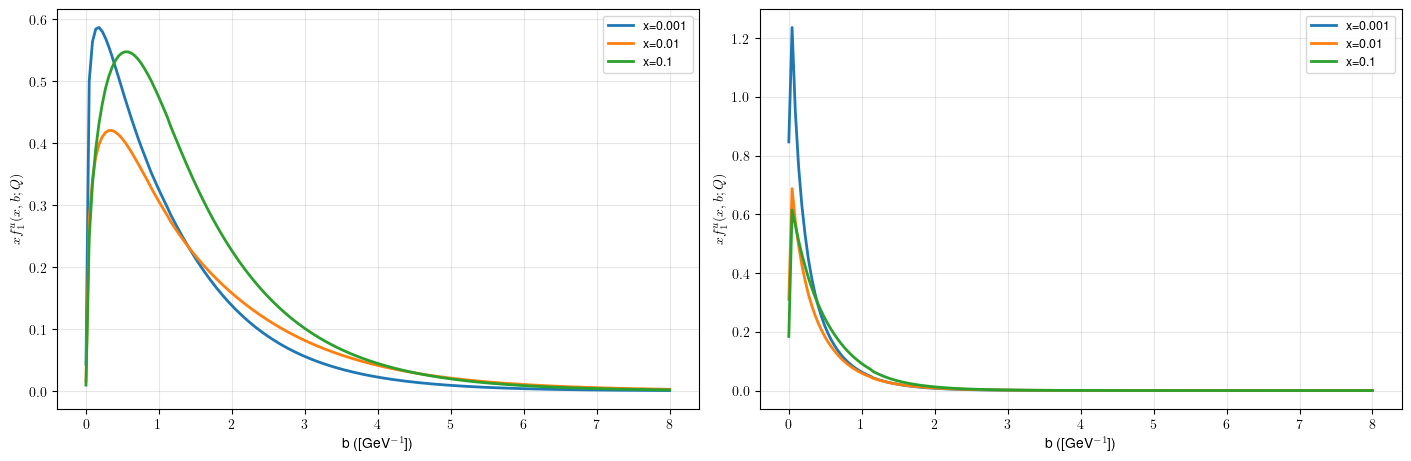

In [6]:
fig_b, axes_b = plt.subplots(1, len(map_Q_values), figsize=(7 * len(map_Q_values), 4.5), constrained_layout=True)
axes_b = np.atleast_1d(axes_b)

for col, Q_value in enumerate(map_Q_values):
    ax_b = axes_b[col]

    for x_value in map_x_values:
        label = f'x={x_value:g}'
        ax_b.plot(b_plot, b_curves[Q_value][x_value], linewidth=2, label=label)

    ax_b.set_xlabel('b ([GeV$^{-1}$])')
    ax_b.set_ylabel(rf'$x f_1^{{{map_plot_flavor}}}(x,b; Q)$')
    ax_b.grid(True, alpha=0.3)
    ax_b.legend(fontsize=9)

plt.show()

# fig_kt, axes_kt = plt.subplots(1, len(map_Q_values), figsize=(7 * len(map_Q_values), 4.5), constrained_layout=True)
# axes_kt = np.atleast_1d(axes_kt)
#
# for col, Q_value in enumerate(map_Q_values):
#     ax_kt = axes_kt[col]
#
#     for x_value in map_x_values:
#         label = f'x={x_value:g}'
#         ax_kt.plot(kt_plot, kt_curves[Q_value][x_value], linewidth=2, label=label)
#
#     ax_kt.set_xlabel(r'$k_T$ [GeV]')
#     ax_kt.set_ylabel(rf'$x f_1^{{{map_plot_flavor}}}(x,k_T; Q)$')
#     ax_kt.grid(True, alpha=0.3)
#     ax_kt.legend(fontsize=9)
#
# plt.show()

In [7]:
summary = []
b_idx = np.argmin(np.abs(b_plot - 0.5))
# kt_idx = np.argmin(np.abs(kt_plot - 1.0))

for Q_value in map_Q_values:
    for x_value in map_x_values:
        summary.append({
            'flavor': map_plot_flavor,
            'Q': Q_value,
            'x': x_value,
            'x_f(b=0.5)': b_curves[Q_value][x_value][b_idx],
            # 'x_f(kT=1.0)': kt_curves[Q_value][x_value][kt_idx],
        })

pd.DataFrame(summary)

,flavor,Q,x,x_f(b=0.5)
0,u,2.0,0.001,0.488664
1,u,2.0,0.010,0.408013
2,u,2.0,0.100,0.545477
3,u,100.0,0.001,0.221221
4,u,100.0,0.010,0.184710
5,u,100.0,0.100,0.246941


3D Surface

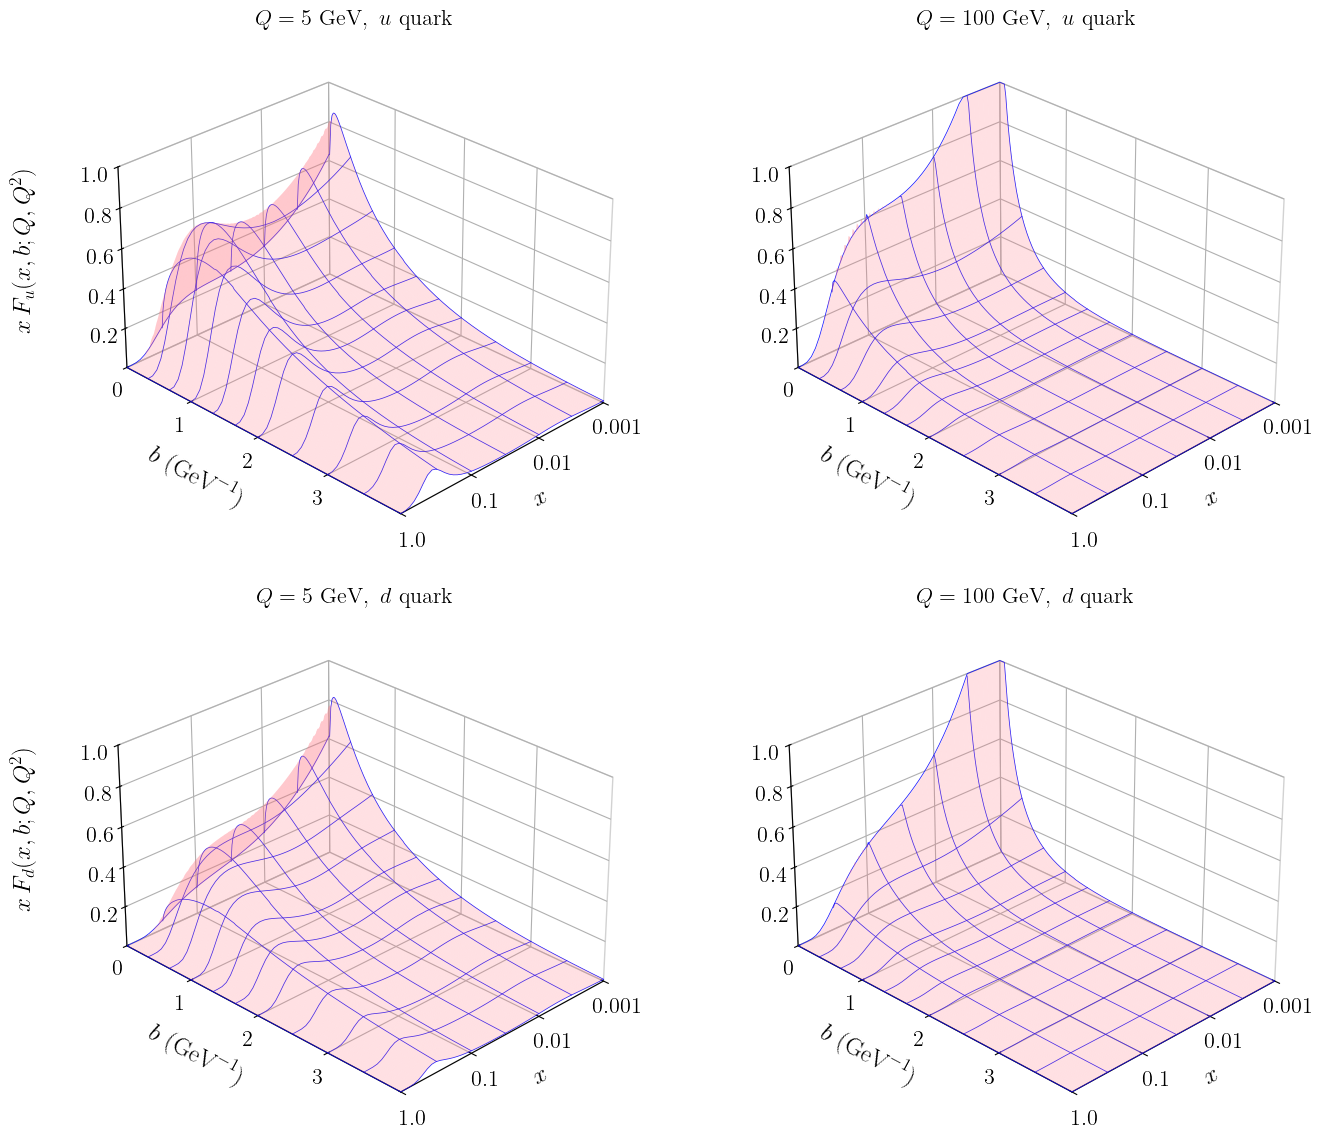

In [8]:
surface_logx = np.log10(surface_x)
# Xkt, Ksurf = np.meshgrid(surface_logx, surface_kt, indexing='ij')
Xb, Bsurf = np.meshgrid(surface_logx, surface_b, indexing='ij')

# surface_kt_plot = np.clip(surface_values, surface_z_min, surface_z_max)
surface_b_plot = {
    flavor_name: {
        Q_value: np.clip(surface_b_values[flavor_name][Q_value], surface_z_min, surface_z_max)
        for Q_value in surface_b_Q_values
    }
    for flavor_name in surface_b_plot_flavors
}

def style_surface(ax, ylabel, zlabel, y_ticks, y_limits, *, zlabel_x=None, zlabel_y=None, ylabel_x=None, ylabel_y=None, z_min=None, z_max=None, z_ticks=None, auto_z=False):
    if zlabel_x is None:
        zlabel_x = surface_zlabel_x_left
    if zlabel_y is None:
        zlabel_y = surface_zlabel_y
    if ylabel_x is None:
        ylabel_x = surface_ylabel_x
    if ylabel_y is None:
        ylabel_y = surface_ylabel_y
    ax.set_facecolor('white')
    for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
        axis.pane.set_facecolor((1.0, 1.0, 1.0, 0.0))
        axis.pane.set_edgecolor('0.65')
    ax.set_xlabel(r'\rm $ x $', fontsize=surface_label_fontsize, labelpad=surface_xlabel_labelpad)
    ax.set_ylabel('')
    ax.set_zlabel('')
    ytext = None
    ztext = None
    if ylabel:
        ytext = ax.text2D(ylabel_x, ylabel_y, ylabel, transform=ax.transAxes, rotation=-28, va='center', ha='center', fontsize=surface_label_fontsize)
    if zlabel:
        ztext = ax.text2D(zlabel_x, zlabel_y, zlabel, transform=ax.transAxes, rotation=90, va='center', ha='center', fontsize=surface_label_fontsize)
    ax._custom_ylabel_text = ytext
    ax._custom_zlabel_text = ztext
    ax.set_xticks(np.log10(surface_x_tick_values))
    ax.set_xticklabels([rf'${label}$' for label in surface_x_tick_labels])
    ax.set_xlim(np.log10(surface_x_min), np.log10(surface_x_tick_values[-1]))
    ax.set_ylim(*y_limits)
    ax.set_yticks(y_ticks)
    if not auto_z:
        if z_min is None:
            z_min = surface_z_min
        if z_max is None:
            z_max = surface_z_max
        if z_ticks is None:
            if np.isclose(z_min, surface_z_min) and np.isclose(z_max, surface_z_max):
                z_ticks = np.arange(0.2, surface_z_max + 0.001, 0.2)
            else:
                z_ticks = np.linspace(z_min, z_max, 5)
        ax.set_zlim(z_min, z_max)
        ax.set_zticks(z_ticks)
    ax.tick_params(axis='x', which='major', pad=1, labelsize=surface_tick_fontsize)
    ax.tick_params(axis='y', which='major', pad=1, labelsize=surface_tick_fontsize)
    ax.tick_params(axis='z', which='major', pad=1, labelsize=surface_tick_fontsize)
    for tick in list(ax.get_xticklabels()) + list(ax.get_yticklabels()) + list(ax.get_zticklabels()):
        tick.set_fontsize(surface_tick_fontsize)
    ax.view_init(elev=28, azim=45)
    ax.set_box_aspect((1.15, 1.55, 0.9))

def build_aligned_line_positions(reference_values, n_lines, *, geometric=False):
    refs = np.array(sorted({float(v) for v in reference_values}), dtype=float)
    if refs.size == 0:
        raise ValueError('reference_values must not be empty')
    n_lines = max(1, int(n_lines))
    if refs.size == 1 or n_lines == 1:
        return np.array([refs[0]], dtype=float)
    if n_lines <= refs.size:
        idx = np.linspace(0, refs.size - 1, n_lines).round().astype(int)
        return refs[idx]
    n_extra = n_lines - refs.size
    n_intervals = refs.size - 1
    extras_per_interval = np.full(n_intervals, n_extra // n_intervals, dtype=int)
    extras_per_interval[: n_extra % n_intervals] += 1
    positions = [refs[0]]
    for interval_idx, extra_count in enumerate(extras_per_interval):
        left = refs[interval_idx]
        right = refs[interval_idx + 1]
        if extra_count > 0:
            if geometric and left > 0 and right > 0:
                inner = np.geomspace(left, right, extra_count + 2)[1:-1]
            else:
                inner = np.linspace(left, right, extra_count + 2)[1:-1]
            positions.extend(inner.tolist())
        positions.append(right)
    return np.array(positions, dtype=float)

def draw_aligned_mesh_lines(ax, x_axis_values, y_axis_values, Z, x_line_values, y_line_values, *, linecolor='blue', linewidth=0.55, alpha=0.90):
    x_axis_values = np.asarray(x_axis_values, dtype=float)
    y_axis_values = np.asarray(y_axis_values, dtype=float)
    for x_value in np.asarray(x_line_values, dtype=float):
        z_line = np.array([np.interp(x_value, x_axis_values, Z[:, col_idx]) for col_idx in range(Z.shape[1])], dtype=float)
        ax.plot(np.full_like(y_axis_values, x_value, dtype=float), y_axis_values, z_line, color=linecolor, linewidth=linewidth, alpha=alpha)
    for y_value in np.asarray(y_line_values, dtype=float):
        z_line = np.array([np.interp(y_value, y_axis_values, Z[row_idx, :]) for row_idx in range(Z.shape[0])], dtype=float)
        ax.plot(x_axis_values, np.full_like(x_axis_values, y_value, dtype=float), z_line, color=linecolor, linewidth=linewidth, alpha=alpha)

def draw_reference_style_surface(ax, X, Y, Z, *, x_axis_values, y_axis_values, x_line_values, y_line_values, facecolor=(1.0, 0.45, 0.50, 0.22), linecolor='blue'):
    ax.plot_surface(
        X,
        Y,
        Z,
        color=facecolor,
        linewidth=0,
        edgecolor='none',
        antialiased=True,
        shade=False,
    )
    draw_aligned_mesh_lines(ax, x_axis_values, y_axis_values, Z, x_line_values, y_line_values, linecolor=linecolor)

surface_x_axis_reference = np.unique(np.array(surface_x_mesh_reference_values, dtype=float))
surface_x_mesh_values = np.log10(build_aligned_line_positions(surface_x_axis_reference, surface_mesh_x_lines, geometric=True))
surface_b_tick_values = np.array(surface_b_tick_values, dtype=float)
surface_b_axis_reference = np.unique(np.array(surface_b_mesh_reference_values, dtype=float))
surface_b_mesh_values = build_aligned_line_positions(surface_b_axis_reference, surface_mesh_b_lines)
# surface_kt_tick_values = np.arange(surface_kt_min, surface_kt_max + 0.1, 0.5)
# surface_kt_axis_reference = np.unique(surface_kt_tick_values.astype(float))
# surface_kt_mesh_values = build_aligned_line_positions(surface_kt_axis_reference, surface_mesh_kt_lines)

fig_b, axes_b = plt.subplots(
    len(surface_b_plot_flavors),
    len(surface_b_Q_values),
    figsize=(surface_figure_width_in, surface_figure_height_in),
    subplot_kw={'projection': '3d'},
)
fig_b.patch.set_facecolor('white')
fig_b.subplots_adjust(left=0.08, right=0.98, bottom=0.04, top=0.96, wspace=surface_subplot_wspace, hspace=surface_subplot_hspace)
axes_b = np.atleast_2d(axes_b)

for row_idx, flavor_name in enumerate(surface_b_plot_flavors):
    for col_idx, Q_value in enumerate(surface_b_Q_values):
        ax_b = axes_b[row_idx, col_idx]
        panel_surface = surface_b_plot[flavor_name][Q_value]
        draw_reference_style_surface(
            ax_b,
            Xb,
            Bsurf,
            panel_surface,
            x_axis_values=surface_logx,
            y_axis_values=surface_b,
            x_line_values=surface_x_mesh_values,
            y_line_values=surface_b_mesh_values,
        )
        style_surface(
            ax_b,
            r'\rm $ b \ (\mathrm{GeV}^{-1}) $',
            rf'\rm $ x\,F_{{{flavor_name}}}(x,b;Q,Q^2) $' if col_idx == 0 else '',
            surface_b_tick_values,
            (surface_b_min, surface_b_max),
            zlabel_x=surface_zlabel_x_left if col_idx == 0 else surface_zlabel_x_right,
        )
        ax_b.set_title(rf'\rm $ Q={Q_value:g} \ \mathrm{{GeV}},\ {flavor_name}\ \mathrm{{quark}} $', fontsize=surface_title_fontsize, pad=surface_title_pad)
plt.show()

# fig_kt = plt.figure(figsize=(0.58 * surface_figure_width_in, 0.62 * surface_figure_height_in))
# fig_kt.patch.set_facecolor('white')
# fig_kt.subplots_adjust(left=0.16, right=0.98, bottom=0.06, top=0.98)
# ax_kt = fig_kt.add_subplot(111, projection='3d')
#
# draw_reference_style_surface(
#     ax_kt,
#     Xkt,
#     Ksurf,
#     surface_kt_plot,
#     x_axis_values=surface_logx,
#     y_axis_values=surface_kt,
#     x_line_values=surface_x_mesh_values,
#     y_line_values=surface_kt_mesh_values,
# )
# style_surface(
#     ax_kt,
#     r'\rm $ k_T \ (\mathrm{GeV}) $',
#     rf'\rm $ x\,F_{{{map_plot_flavor}}}(x,k_T;Q,Q^2) $',
#     np.arange(0, surface_kt_max + 0.1, 0.5),
#     (surface_kt_min, surface_kt_max),
# )
# plt.show()

u/d ratio surface: 100%|██████████| 120/120 [00:09<00:00, 13.13it/s]


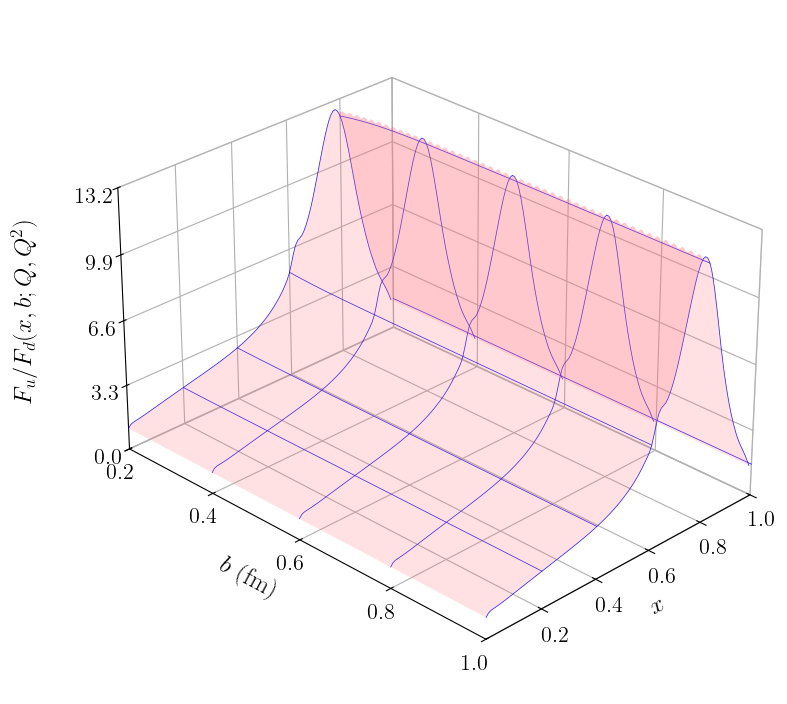

In [9]:
ratio_surface_x = np.linspace(surface_ratio_x_min, surface_x_max, n_ratio_x)
ratio_b = np.linspace(
    ratio_curve_b_plot_min_fm * ratio_b_unit_divisor,
    ratio_curve_b_plot_max_fm * ratio_b_unit_divisor,
    n_ratio_b,
)
surface_ud_ratio_plot = np.vstack([
    np.divide(
        u_vals,
        d_vals,
        out=np.full_like(u_vals, np.nan, dtype=float),
        where=np.abs(d_vals) > 1e-12,
    )
    for x_value in tqdm(ratio_surface_x, desc='u/d ratio surface')
    for u_vals, d_vals in [(
        np.array([
            eval_component_b_flavor('u', x_value, surface_ratio_Q, b_value)
            for b_value in ratio_b
        ], dtype=float),
        np.array([
            eval_component_b_flavor('d', x_value, surface_ratio_Q, b_value)
            for b_value in ratio_b
        ], dtype=float),
    )]
])

ratio_surface_b_fm = ratio_b / ratio_b_unit_divisor
ratio_Xb, ratio_Bsurf = np.meshgrid(ratio_surface_x, ratio_surface_b_fm, indexing='ij')
ratio_x_tick_values = [
    x for x in surface_ratio_x_tick_values
    if surface_ratio_x_min <= x <= surface_ratio_x_max
]
ratio_x_mesh_values = np.array(ratio_x_tick_values, dtype=float)
ratio_b_tick_values = np.array(ratio_b_tick_values_fm, dtype=float)
ratio_b_axis_reference = np.unique(np.array([
    ratio_curve_b_plot_min_fm,
    *ratio_b_tick_values_fm,
    ratio_curve_b_plot_max_fm,
], dtype=float))
ratio_b_mesh_values = ratio_b_axis_reference

fig_ratio = plt.figure(figsize=(0.58 * surface_figure_width_in, 0.62 * surface_figure_height_in))
fig_ratio.patch.set_facecolor('white')
fig_ratio.subplots_adjust(left=0.12, right=0.98, bottom=0.06, top=0.98)
ax_ratio = fig_ratio.add_subplot(111, projection='3d')
ratio_surface = surface_ud_ratio_plot
draw_reference_style_surface(
    ax_ratio,
    ratio_Xb,
    ratio_Bsurf,
    ratio_surface,
    x_axis_values=ratio_surface_x,
    y_axis_values=ratio_surface_b_fm,
    x_line_values=ratio_x_mesh_values,
    y_line_values=ratio_b_mesh_values,
)
style_surface(
    ax_ratio,
    r'\rm $ b \ (\mathrm{fm}) $',
    r'\rm $ F_u/F_d(x,b;Q,Q^2) $',
    ratio_b_tick_values,
    (ratio_curve_b_plot_min_fm, ratio_curve_b_plot_max_fm),
    zlabel_x=surface_ratio_zlabel_x,
    zlabel_y=surface_ratio_zlabel_y,
    ylabel_x=surface_ratio_ylabel_x,
    ylabel_y=surface_ratio_ylabel_y,
    z_min=0.0,
    z_max=float(np.nanmax(ratio_surface)),
)
ax_ratio.set_xticks(ratio_x_tick_values)
ax_ratio.set_xticklabels([rf'${x:.1f}$' for x in ratio_x_tick_values])
ax_ratio.set_xlim(surface_ratio_x_max, surface_ratio_x_min)
plt.show()


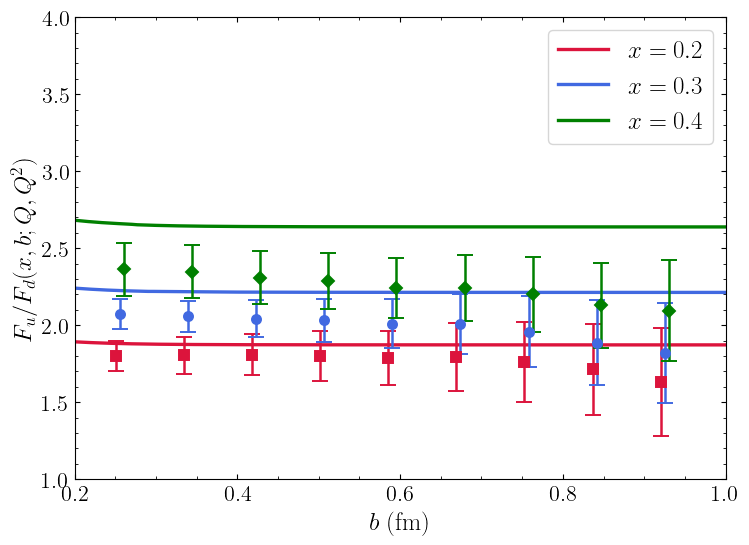

In [10]:
marker_symbol_map = {'square': 's', 'circle': 'o', 'diamond': 'D'}
lattice_ratio_df = pd.read_csv(lattice_ratio_csv_path)
lattice_ratio_plot_df = lattice_ratio_df[
    lattice_ratio_df['b_fm'].between(ratio_curve_b_plot_min_fm, ratio_curve_b_plot_max_fm)
].copy()

ratio_curve_values = {
    x_value: np.divide(
        u_vals,
        d_vals,
        out=np.full_like(u_vals, np.nan, dtype=float),
        where=np.abs(d_vals) > 1e-12,
    )
    for x_value in ratio_curve_x_values
    for u_vals, d_vals in [(
        np.array([
            eval_component_b_flavor('u', x_value, surface_ratio_Q, b_value)
            for b_value in ratio_b
        ], dtype=float),
        np.array([
            eval_component_b_flavor('d', x_value, surface_ratio_Q, b_value)
            for b_value in ratio_b
        ], dtype=float),
    )]
}

fig_ratio_curves, ax_ratio_curves = plt.subplots(figsize=(8.4, 6.0))
for x_value, color in zip(ratio_curve_x_values, ratio_curve_colors):
    ax_ratio_curves.plot(
        ratio_surface_b_fm,
        ratio_curve_values[x_value],
        color=color,
        linewidth=ratio_curve_linewidth,
        label=rf'$x={x_value:g}$',
    )

    lattice_subset = lattice_ratio_plot_df[np.isclose(lattice_ratio_plot_df['x'], x_value)]
    if not lattice_subset.empty:
        marker_name = lattice_subset['marker'].iloc[0]
        ax_ratio_curves.errorbar(
            lattice_subset['b_fm'],
            lattice_subset['central'],
            yerr=lattice_subset['std'],
            fmt=marker_symbol_map.get(marker_name, 'o'),
            linestyle='none',
            markersize=lattice_ratio_marker_size,
            markeredgewidth=lattice_ratio_marker_edge_width,
            color=color,
            markerfacecolor=color,
            markeredgecolor=color,
            elinewidth=lattice_ratio_elinewidth,
            capsize=lattice_ratio_capsize,
            capthick=lattice_ratio_capthick,
            zorder=lattice_ratio_zorder,
        )

ax_ratio_curves.set_xlim(ratio_curve_b_plot_min_fm, ratio_curve_b_plot_max_fm)
ax_ratio_curves.set_xticks(ratio_b_tick_values_fm)
ax_ratio_curves.set_ylim(1.0, 4.0)
ax_ratio_curves.set_xlabel(r'$b \ (\mathrm{fm})$', fontsize=surface_label_fontsize)
ax_ratio_curves.set_ylabel(r'$F_u/F_d(x,b;Q,Q^2)$', fontsize=surface_label_fontsize)
ax_ratio_curves.tick_params(axis='both', which='major', direction='in', top=True, right=True, labelsize=surface_tick_fontsize)
ax_ratio_curves.tick_params(axis='both', which='minor', direction='in', top=True, right=True)
ax_ratio_curves.minorticks_on()
ax_ratio_curves.legend(frameon=True, fontsize=surface_label_fontsize)
plt.show()


replica ratio bands: x=0.4: 100%|██████████| 100/100 [00:00<00:00, 212.49it/s]


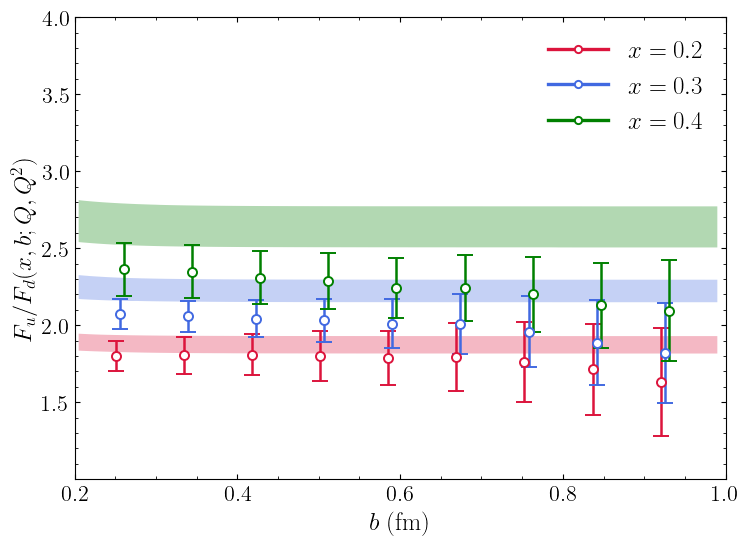

In [14]:
lattice_marker_symbol = 'o'
lattice_ratio_df = pd.read_csv(lattice_ratio_csv_path)
lattice_ratio_plot_df = lattice_ratio_df[
    lattice_ratio_df['b_fm'].between(ratio_curve_b_plot_min_fm, ratio_curve_b_plot_max_fm)
].copy()

replica_ratio_grid_dir_candidates = [
    Path(f'Grids/{ratio_grid_table_name}/TMDPDF_ratio_plot'),
    Path(f'TMDs/Grids/{ratio_grid_table_name}/TMDPDF_ratio_plot'),
]
replica_ratio_grid_dir = next(path for path in replica_ratio_grid_dir_candidates if path.exists())
replica_ratio_grid_files = sorted(replica_ratio_grid_dir.glob('*.csv'), key=lambda path: int(path.stem))
replica_ratio_quantiles = (0.15865, 0.5, 0.84135)
replica_ratio_band_alpha = 0.3

replica_ratio_band_data = {}
for x_value in ratio_curve_x_values:
    replica_ratio_curves = []
    ratio_b_plot_fm = None

    for grid_path in tqdm(replica_ratio_grid_files, desc=rf'replica ratio bands: x={x_value:g}'):
        grid_df = pd.read_csv(grid_path, usecols=['x', 'b', 'f_u', 'f_d'])
        subset = grid_df[np.isclose(grid_df['x'], x_value)].copy()
        subset['b_fm'] = subset['b'] / ratio_b_unit_divisor
        subset = subset[subset['b_fm'].between(ratio_curve_b_plot_min_fm, ratio_curve_b_plot_max_fm)]

        current_b_fm = subset['b_fm'].to_numpy(dtype=float)
        if ratio_b_plot_fm is None:
            ratio_b_plot_fm = current_b_fm
        elif not np.allclose(current_b_fm, ratio_b_plot_fm):
            raise ValueError(f'Inconsistent b grid in {grid_path.name} for x={x_value:g}')

        ratio_values = np.divide(
            subset['f_u'].to_numpy(dtype=float),
            subset['f_d'].to_numpy(dtype=float),
            out=np.full(len(subset), np.nan, dtype=float),
            where=np.abs(subset['f_d'].to_numpy(dtype=float)) > 1e-12,
        )
        replica_ratio_curves.append(ratio_values)

    ratio_stack = np.vstack(replica_ratio_curves)
    ratio_lo, ratio_mid, ratio_hi = np.quantile(ratio_stack, replica_ratio_quantiles, axis=0)
    replica_ratio_band_data[x_value] = {
        'b_fm': ratio_b_plot_fm,
        'lo': ratio_lo,
        'mid': ratio_mid,
        'hi': ratio_hi,
    }

fig_replica_ratio_bands, ax_replica_ratio_bands = plt.subplots(figsize=(8.4, 6.0))
legend_handles = []
for x_value, color in zip(ratio_curve_x_values, ratio_curve_colors):
    band = replica_ratio_band_data[x_value]
    ax_replica_ratio_bands.fill_between(
        band['b_fm'],
        band['lo'],
        band['hi'],
        color=color,
        alpha=replica_ratio_band_alpha,
        linewidth=0,
        zorder=1,
    )
    #ax_replica_ratio_bands.plot(
    #    band['b_fm'],
    #    band['mid'],
    #    color=color,
    #    linewidth=ratio_curve_linewidth,
    #    zorder=2,
    #)

    lattice_subset = lattice_ratio_plot_df[np.isclose(lattice_ratio_plot_df['x'], x_value)]
    marker_name = lattice_subset['marker'].iloc[0] if not lattice_subset.empty else 'circle'
    if not lattice_subset.empty:
        ax_replica_ratio_bands.errorbar(
            lattice_subset['b_fm'],
            lattice_subset['central'],
            yerr=lattice_subset['std'],
            fmt=lattice_marker_symbol,
            linestyle='none',
            markersize=lattice_ratio_marker_size,
            markeredgewidth=lattice_ratio_marker_edge_width,
            color=color,
            markerfacecolor='white',
            markeredgecolor=color,
            elinewidth=lattice_ratio_elinewidth,
            capsize=lattice_ratio_capsize,
            capthick=lattice_ratio_capthick,
            zorder=lattice_ratio_zorder,
        )

    legend_handles.append(
        plt.Line2D(
            [], [],
            color=color,
            linewidth=ratio_curve_linewidth,
            marker=lattice_marker_symbol,
            markersize=0.8 * lattice_ratio_marker_size,
            markeredgewidth=lattice_ratio_marker_edge_width,
            markerfacecolor='white',
            markeredgecolor=color,
            label=rf'$x={x_value:g}$',
        )
    )

ax_replica_ratio_bands.set_xlim(ratio_curve_b_plot_min_fm, ratio_curve_b_plot_max_fm)
ax_replica_ratio_bands.set_xticks(ratio_b_tick_values_fm)
ax_replica_ratio_bands.set_ylim(1.0, 4.0)
ax_replica_ratio_bands.set_yticks([1.5, 2.0, 2.5, 3.0, 3.5, 4.0])
ax_replica_ratio_bands.set_xlabel(r'$b \ (\mathrm{fm})$', fontsize=surface_label_fontsize)
ax_replica_ratio_bands.set_ylabel(r'$F_u/F_d(x,b;Q,Q^2)$', fontsize=surface_label_fontsize)
ax_replica_ratio_bands.tick_params(axis='both', which='major', direction='in', top=True, right=True, labelsize=surface_tick_fontsize)
ax_replica_ratio_bands.tick_params(axis='both', which='minor', direction='in', top=True, right=True)
ax_replica_ratio_bands.minorticks_on()
ax_replica_ratio_bands.legend(handles=legend_handles, frameon=False, fontsize=surface_label_fontsize, handlelength=2.4)
plt.show()
